In [1]:
from mylib.statistic_test import *
from mazepy.datastruc.neuact import SpikeTrain, TuningCurve
from mazepy.datastruc.variables import VariableBin

code_id = "0877 - Revisit Stability"
loc = join(figpath, "Dsp", code_id)
mkdir(loc)
saved_dir = join(loc, "Retrieval Results")
dir_name = join(figpath, "Dsp", "Reforming Neural Trajectory Analysis") 
mkdir(saved_dir)
pass

d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


        D:\Data\FinalResults\Dsp\0877 - Revisit Stability is already existed!
        D:\Data\FinalResults\Dsp\0877 - Revisit Stability\Retrieval Results is already existed!


In [2]:
from scipy.optimize import curve_fit

# logistic function
def logistic(t, k, t0):
    return 1 / (1 + np.exp(-k * (t - t0)))

def gaussian_kernel(x, sigma=1.0):
    """Gaussian kernel function."""
    y = np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    return y/np.sum(y)

def hidden_state_proportion(
    mouse: int,
    maze_type: int,
    rt: int = 0
):
    if exists(join(saved_dir, f"{mouse}_behav_R{rt+1}.pkl")):
        with open(join(saved_dir, f"{mouse}_behav_R{rt+1}.pkl"), 'rb') as f:
            return pickle.load(f)
    else:
        with open(join(dir_name, f"{mouse}.pkl"), 'rb') as f:
            res = pickle.load(f)
            
        hidden_state_traj = res['raw_hidden_state_traj']
        session_traj = res['raw_session_traj']
        route_traj = res['raw_route_traj']
        nodes_traj = res['raw_nodes_traj']
        father_nodes_traj = S2F[nodes_traj-1]
        lap_traj = res['raw_lap_traj']
        time_traj = res['raw_time_traj']
        dt = np.zeros_like(time_traj, np.float64)
        
        beg = np.concatenate(([0], np.where(np.diff(lap_traj) != 0)[0] + 1))
        end = np.concatenate((np.where(np.diff(lap_traj) != 0)[0] + 1, [len(lap_traj)]))
        for i in range(len(beg)):
            dt[beg[i]:end[i]] = np.diff(time_traj[beg[i]:end[i]], prepend=time_traj[beg[i]])
        
        if rt == 0:
            state_sum = np.zeros((144, 7*4))
            time_sum = np.zeros((144, 7*4))
            for s in range(7):
                n_lap = np.unique(lap_traj[(route_traj == 0) & (session_traj == s)])
                
                division = np.concatenate([np.arange(0, n_lap.shape[0], int(n_lap.shape[0]/4)+1), [n_lap.shape[0]]])
                for i in range(division.shape[0]-1):
                    for b in CP_DSPs[maze_type][0]:
                        idx = np.where(
                            (np.isin(lap_traj, n_lap[division[i]:division[i+1]])) &
                            (session_traj == s) &
                            (route_traj == 0) & 
                            (father_nodes_traj == b)
                        )[0]
                        
                        if idx.shape[0] < 1:
                            continue                
                    
                        state_sum[b-1, s*4 + i] = np.sum((1-hidden_state_traj[idx]) * dt[idx])
                        time_sum[b-1, s*4 + i] = np.sum(dt[idx])
            
            prop = np.zeros((144, 7*4))
            for j in range(prop.shape[1]):
                
                prop[CP_DSPs[maze_type][0]-1, j] = (
                    np.convolve(state_sum[CP_DSPs[maze_type][0]-1, j], np.ones(7), mode='same') /
                    np.convolve(time_sum[CP_DSPs[maze_type][0]-1, j], np.ones(7), mode='same')
                )
            
            with open(join(saved_dir, f"{mouse}_behav_R{rt+1}.pkl"), 'wb') as f:
                pickle.dump(prop, f)
            
            return prop
        else:
            state_sum = np.zeros((144, 7))
            time_sum = np.zeros((144, 7))
            for s in range(7):
                for b in CP_DSPs[maze_type][rt]:
                    idx = np.where(
                        (route_traj == rt) &
                        (session_traj == s) & 
                        (father_nodes_traj == b)
                    )[0]
                    
                    if idx.shape[0] < 1:
                        continue
                    
                    state_sum[b-1, s] = np.sum((1-hidden_state_traj[idx]) * dt[idx])
                    time_sum[b-1, s] = np.sum(dt[idx])
                    
            prop = np.zeros((144, 7))
            for j in range(prop.shape[1]):
                prop[CP_DSPs[maze_type][rt]-1, j] = (
                    np.convolve(state_sum[CP_DSPs[maze_type][rt]-1, j], np.ones(7), mode='same') /
                    np.convolve(time_sum[CP_DSPs[maze_type][rt]-1, j], np.ones(7), mode='same')
                )
                
            #if rt == 3:
            #    prop *= np.nan
            if rt == 6:
                convert_session = np.where(session_convertor[mouse] >= 0)[0][0]
                prop[:, convert_session:] = np.nan
                
            with open(join(saved_dir, f"{mouse}_behav_R{rt+1}.pkl"), 'wb') as f:
                pickle.dump(prop, f)
            return prop

maze_type = 1
for mouse in [10212, 10224, 10227, 10232]:
    for r in range(7):
        hidden_state_proportion(mouse, maze_type, r)
prop_r0 = hidden_state_proportion(10232, maze_type, 0)

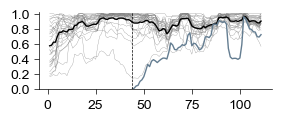

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29684\1446333020.py:54: RuntimeWarning: divide by zero encountered in divide
  prop_r5[CP_DSPs[maze_type][5]-1, 0]/mean_prop_r0[CP_DSPs[maze_type][5]-1],


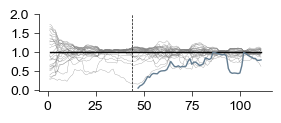

In [47]:
maze_type = 1
prop_r0 = hidden_state_proportion(10232, maze_type, 0)
prop_r5 = hidden_state_proportion(10232, maze_type, 5)
fig = plt.figure(figsize=(3, 1))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
for i in range(prop_r0.shape[1]):
    ax.plot(
        np.arange(1, 112),
        prop_r0[CP_DSPs[maze_type][0]-1, i],
        color='grey',
        lw=0.2
    )
ax.plot(
    np.arange(1, 112),
    np.nanmean(prop_r0[CP_DSPs[maze_type][0]-1, :], axis=1),
    color='k',
    lw=1
)
#idx = np.where(prop_r5[CP_DSPs[maze_type][5]-1, 0] - bottom_line_whole[CP_DSPs[maze_type][5]-1] >= 0)[0]
ax.plot(
    np.arange(1, 112)[-CP_DSPs[maze_type][5].shape[0]:],
    prop_r5[CP_DSPs[maze_type][5]-1, 0],
    color=DSPPalette[5],
    lw=1
)
ax.axvline(np.arange(1, 112)[-CP_DSPs[maze_type][5].shape[0]:][idx[0]], color='k', lw=0.5, ls='--')
ax.set_ylim(0, 1.02)
ax.set_yticks(np.linspace(0, 1, 6))
plt.savefig(join(loc, "Hidden State Retrieval [Example].png"), dpi=600)
plt.savefig(join(loc, "Hidden State Retrieval [Example].svg"), dpi=600)
plt.show()


maze_type = 1
mean_prop_r0 = np.nanmean(prop_r0, axis=1)
fig = plt.figure(figsize=(3, 1))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
for i in range(prop_r0.shape[1]):
    ax.plot(
        np.arange(1, 112),
        prop_r0[CP_DSPs[maze_type][0]-1, i]/mean_prop_r0[CP_DSPs[maze_type][0]-1],
        color='grey',
        lw=0.2
    )
ax.plot(
    np.arange(1, 112),
    np.nanmean(prop_r0[CP_DSPs[maze_type][0]-1, :], axis=1)/mean_prop_r0[CP_DSPs[maze_type][0]-1],
    color='k',
    lw=1
)
#idx = np.where(prop_r5[CP_DSPs[maze_type][5]-1, 0] - bottom_line_whole[CP_DSPs[maze_type][5]-1] >= 0)[0]
ax.plot(
    np.arange(1, 112)[-CP_DSPs[maze_type][5].shape[0]:],
    prop_r5[CP_DSPs[maze_type][5]-1, 0]/mean_prop_r0[CP_DSPs[maze_type][5]-1],
    color=DSPPalette[5],
    lw=1
)
ax.axvline(np.arange(1, 112)[-CP_DSPs[maze_type][5].shape[0]:][idx[0]], color='k', lw=0.5, ls='--')
ax.set_yticks(np.linspace(0, 2, 5))
plt.savefig(join(loc, "Hidden State Retrieval [Normed Example].png"), dpi=600)
plt.savefig(join(loc, "Hidden State Retrieval [Normed Example].svg"), dpi=600)
plt.show()

In [13]:
def get_index_map(mouse: int) -> np.ndarray:
    idx = np.where(f_CellReg_dsp['MiceID'] == mouse)[0][0]
    with open(f_CellReg_dsp['cellreg_folder'][idx], 'rb') as f:
        index_map = pickle.load(f).astype(np.int64)
        
    if mouse != 10232:
        index_map = index_map[1:, :]
    
    return index_map

def cross_day_stability(mouse, rt: int):
    if exists(join(saved_dir, f" {mouse}_neural.pkl")):
        with open(join(saved_dir, f"{mouse}_neural.pkl"), 'rb') as f:
            cross_day_stability = pickle.load(f)
        
        if rt == 0:
            return np.stack((cross_day_stability[:, :, 0], cross_day_stability[:, :, 4]), axis=2)
        else:
            if rt in [1,2,3]:
                return cross_day_stability[:, :, rt:rt+1]
            else:
                return cross_day_stability[:, :, rt+1:rt+2]
    else:
        file_idx = np.where(f2['MiceID'] == mouse)[0]
        index_map = get_index_map(mouse)
        
        traces = []
        print("Upload:")
        for i in tqdm(range(7)):
            with open(f2['Trace File'][file_idx[i]], 'rb') as f:
                trace = pickle.load(f)
            traces.append(trace)
            
        cross_day_corr = np.zeros((144, 6, 8, 2)) # Bin x Session x Route
        for s in tqdm(range(6)):
            cell_idx = np.where((index_map[s, :] > 0) & (index_map[s+1, :] > 0))[0]
            
            for j, nodes in enumerate([0, 1, 2, 3, 5, 6, 7, 8]):
                rt_map_prev = traces[s][f'node {nodes}']['smooth_map_all'][index_map[s, cell_idx]-1, :]
                #rt_map_prev = traces[s][f'node {nodes}']['old_map_clear'][index_map[s, cell_idx]-1, :]
                rt_map_next = traces[s+1][f'node {nodes}']['smooth_map_all'][index_map[s+1, cell_idx]-1, :]
                #rt_map_next = traces[s+1][f'node {nodes}']['old_map_clear'][index_map[s+1, cell_idx]-1, :]
                for b in range(144):
                    sonbins = np.asarray(Father2SonGraph[b+1], dtype=np.int64)
                    """cross_day_corr[b, s, j, 0] = np.corrcoef(rt_map_prev[:, b], rt_map_next[:, b])[0, 1]
                    cross_day_corr[b, s, j, 1] = np.corrcoef(
                        np.random.permutation(rt_map_prev[:, b]), 
                        np.random.permutation(rt_map_next[:, b])
                    )[0, 1]
                    """
                    cross_day_corr[b, s, j, 0] = np.corrcoef(rt_map_prev[:, sonbins-1].flatten(), rt_map_next[:, sonbins-1].flatten())[0, 1]
                    cross_day_corr[b, s, j, 1] = np.corrcoef(
                        np.random.permutation(rt_map_prev[:, sonbins-1].flatten()), 
                        np.random.permutation(rt_map_next[:, sonbins-1].flatten())
                    )[0, 1]
                    
        with open(join(saved_dir, f"{mouse}_neural.pkl"), 'wb') as f:
            pickle.dump(cross_day_corr, f)
            
def apvc(mouse, rt):
    if exists(join(saved_dir, f"{mouse}_apvc.pkl")):
        with open(join(saved_dir, f"{mouse}_apvc.pkl"), 'rb') as f:
            apvc_data = pickle.load(f)
    else:
        file_idx = np.where(f2['MiceID'] == mouse)[0]
        
        apvc_data = np.zeros((144, 7, 8))
        for s in tqdm(range(7)):
            with open(f2['Trace File'][file_idx[s]], 'rb') as f:
                trace = pickle.load(f)

            for i, rt, nodes in zip(range(8), [1, 2, 3, 0, 4, 5, 6, 0], [1, 2, 3, 4, 6, 7, 8, 9]):
                if nodes < 5:
                    targ_nodes = 0
                else:
                    targ_nodes = 5
                    
                for b in range(144):
                    sonbins = np.asarray(Father2SonGraph[b+1], dtype=np.int64)
                    apvc_data[b, s, i] = np.corrcoef(
                        trace[f'node {nodes}']['smooth_map_all'][:, sonbins-1].flatten(),
                        trace[f'node {targ_nodes}']['smooth_map_all'][:, sonbins-1].flatten()
                    )[0, 1]
            
            del trace
                    
        with open(join(saved_dir, f"{mouse}_apvc.pkl"), 'wb') as f:
            pickle.dump(apvc_data, f)

    return apvc_data



maze_type = 1
def new_map_stability(mouse, rt: int):
    if exists(join(saved_dir, f"{mouse}_new_map.pkl")):
        with open(join(saved_dir, f"{mouse}_new_map.pkl"), 'rb') as f:
            cross_day_stability = pickle.load(f)
        
        if rt == 0:
            return np.stack((cross_day_stability[:, 0, :], cross_day_stability[:, 4, :]), axis=2)
        else:
            if rt in [1,2,3]:
                return cross_day_stability[:, rt:rt+1, :]
            else:
                return cross_day_stability[:, rt+1:rt+2, :]
    else:
        file_idx = np.where(f2['MiceID'] == mouse)[0]
        index_map = get_index_map(mouse)
        
        traces = []
        print("Upload:")
        for i in tqdm(range(7)):
            with open(f2['Trace File'][file_idx[i]], 'rb') as f:
                trace = pickle.load(f)
            traces.append(trace)
            
        cross_day_corr = np.zeros((6, 8, 2)) # Bin x Session x Route
        D = GetDMatrices(maze_type, 48)
        for s in range(6):
            cell_idx = np.where((index_map[s, :] > 0) & (index_map[s+1, :] > 0))[0]
            
            for j, nodes in enumerate([0, 1, 2, 3, 5, 6, 7, 8]):
                rt_map_prev = traces[s][f'node {nodes}']['smooth_map_all'][index_map[s, cell_idx]-1, :]
                rt_map_next = traces[s+1][f'node {nodes}']['smooth_map_all'][index_map[s+1, cell_idx]-1, :]
                
                if j in [0, 4]:
                    cross_day_corr[s, j, 0] = np.corrcoef(rt_map_prev[:, :].flatten(), rt_map_next[:, :].flatten())[0, 1]
                    cross_day_corr[s, j, 1] = np.corrcoef(
                        np.random.permutation(rt_map_prev[:, :].flatten()), 
                        np.random.permutation(rt_map_next[:, :].flatten())
                    )[0, 1]
                else:
                    if j in [1, 2, 3]:
                        targ_map_prev = traces[s][f'node 0']['smooth_map_all'][index_map[s, cell_idx]-1, :]
                        targ_map_next = traces[s+1][f'node 0']['smooth_map_all'][index_map[s+1, cell_idx]-1, :]
                        rt = j
                    else:
                        targ_map_prev = traces[s][f'node 5']['smooth_map_all'][index_map[s, cell_idx]-1, :]
                        targ_map_next = traces[s+1][f'node 5']['smooth_map_all'][index_map[s+1, cell_idx]-1, :]
                        rt = j-1
                        
                    retriev_curve_prev = np.zeros(CP_DSPs[maze_type][rt].shape[0]*16)
                    retriev_curve_next = np.zeros(CP_DSPs[maze_type][rt].shape[0]*16)
                    sonbins = np.concatenate([Father2SonGraph[b] for b in CP_DSPs[maze_type][rt]])
                    for k, b in enumerate(sonbins):
                        retriev_curve_prev[k] = np.corrcoef(rt_map_prev[:, b-1], targ_map_prev[:, b-1])[0, 1]
                        retriev_curve_next[k] = np.corrcoef(rt_map_next[:, b-1], targ_map_next[:, b-1])[0, 1]
                    retriev_curve_prev[np.isnan(retriev_curve_prev)] = 0
                    retriev_curve_next[np.isnan(retriev_curve_next)] = 0
                    
                    bin_argsort = np.argsort(D[sonbins-1, 2303])[::-1]
                    try:
                        retriv_point_prev = np.where(retriev_curve_prev[bin_argsort] > 0.3)[0][0]
                    except:
                        retriv_point_prev = retriev_curve_prev.shape[0]
                    try:
                        retriv_point_next = np.where(retriev_curve_next[bin_argsort] > 0.3)[0][0]
                    except:
                        retriv_point_next = retriev_curve_next.shape[0]
                
                    included_bins = sonbins[bin_argsort][:min(retriv_point_prev, retriv_point_next)]-1
                    
                    if included_bins.shape[0] >= 16:
                        cross_day_corr[s, j, 0] = np.corrcoef(rt_map_prev[:, included_bins].flatten(), rt_map_next[:, included_bins].flatten())[0, 1]
                        cross_day_corr[s, j, 1] = np.corrcoef(
                            np.random.permutation(rt_map_prev[:, included_bins].flatten()),
                            np.random.permutation(rt_map_next[:, included_bins].flatten())
                        )[0, 1]
                    else:
                        cross_day_corr[s, j, 0] = np.nan
                        cross_day_corr[s, j, 1] = np.nan
            
        with open(join(saved_dir, f"{mouse}_new_map.pkl"), 'wb') as f:
            pickle.dump(cross_day_corr, f)

cross_day_stability(10212, 0)
cross_day_stability(10224, 0)
cross_day_stability(10227, 0)
cross_day_stability(10232, 0) 

new_map_stability(10212, 0)
new_map_stability(10224, 0)
new_map_stability(10227, 0)
new_map_stability(10232, 0)

for mouse in [10212, 10224, 10227, 10232]:
    apvc_data = apvc(mouse, 0)

Upload:


  0%|          | 0/6 [00:00<?, ?it/s]d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
100%|██████████| 6/6 [00:02<00:00,  2.39it/s]


Upload:


  0%|          | 0/6 [00:00<?, ?it/s]d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: divide by zero encountered in divide
  c /= stddev[:, None]
d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: divide by zero encountered in divide
  c /= stddev[None, :]
100%|██████████| 6/6 [00:02<00:00,  2.10it/s]


Upload:


100%|██████████| 6/6 [00:03<00:00,  1.75it/s]


Upload:


100%|██████████| 6/6 [00:03<00:00,  1.90it/s]


# Cross-day Stability Changes

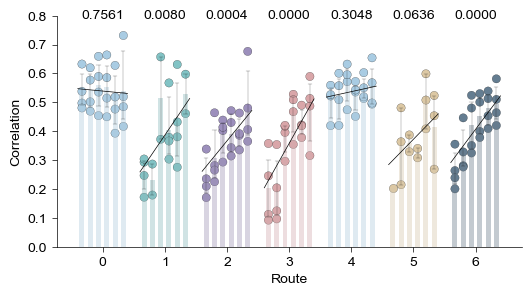

In [28]:
if exists(join(figdata, f"{code_id} [Cross-Day Stability Change].pkl")) == False:
    Stability = { 
        'MiceID': [],
        'Correlation': [],
        'Session': [],
        'Route': [],
        'Type': []
    }
    
    for mouse in [10212, 10224, 10227, 10232]:
        with open(join(saved_dir, f"{mouse}_new_map.pkl"), 'rb') as f:
            neural_stability = pickle.load(f)
            
        for s in range(6):
            rts = [0, 1, 2, 3, 0, 4, 5, 6]
            for j in range(8):
                for stype in ["Data", "Shuffle"]:
                    Stability['MiceID'].append(mouse)
                    Stability['Session'].append(s)
                    Stability['Route'].append(j)
                    Stability['Type'].append(stype)
                    Stability['Correlation'].append(neural_stability[s, j, 0] if stype == "Data" else neural_stability[s, j, 1])
        
    for key in Stability.keys():
        Stability[key] = np.array(Stability[key])   
    
    with open(join(figdata, f"{code_id} [Cross-Day Stability Change].pkl"), 'wb') as f:
        pickle.dump(Stability, f)
        
    StabilityD = pd.DataFrame(Stability)
    StabilityD.to_excel(join(figdata, f"{code_id} [Cross-Day Stability Change].xlsx"), index=False)
    print(len(StabilityD))
else:
    with open(join(figdata, f"{code_id} [Cross-Day Stability Change].pkl"), 'rb') as f:
        Stability = pickle.load(f)

SubData1 = SubDict(
    Stability, 
    Stability.keys(), 
    np.where((Stability['Type'] == "Data")&(Stability['Route'] != 7))[0]
)
fig = plt.figure(figsize=(6, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
colors = DSPPalette[:4] + DSPPalette[:1] + DSPPalette[4:7]
for rt in range(7):
    subdata_rt = SubDict(
        SubData1, 
        SubData1.keys(), 
        np.where((SubData1['Route'] == rt))[0]
    )
    sns.stripplot(
        data=subdata_rt,
        x='Route',
        y='Correlation',
        hue='Session',
        palette=[colors[rt]]*6,
        linewidth=0.15,
        edgecolor='k',
        size=6,
        dodge=True,
        jitter=0,
        ax=ax,
        zorder=1,
        legend=False
    )
    sns.barplot(
        data=subdata_rt,
        x='Route',
        y='Correlation',
        hue='Session',
        palette=[colors[rt]]*6,
        capsize=0.4, 
        err_kws={'linewidth': 0.15, 'color':'k'},
        ax=ax,
        legend=False,
        gap=0.4,
        width=0.8,
        zorder=2,
        alpha=0.4
    )
    idx = np.where(np.isnan(subdata_rt['Correlation']) == False)[0]
    reg = linregress(subdata_rt['Session'][idx], subdata_rt['Correlation'][idx])
    x = np.array([-0.4, +0.4])
    xx = np.array([0, 5])
    y = reg.slope * xx + reg.intercept
    ax.plot(x+rt, y, color='k', linewidth=0.5, zorder=3)
    ax.text(rt, 0.8, f"{reg.pvalue:.4f}", ha='center', va='center')
    
ax.set_ylim(0, 0.8)
plt.savefig(join(loc, f"Stability Increase.svg"), dpi=300)
plt.savefig(join(loc, f"Stability Increase.png"), dpi=300)
plt.show()

# Behavioral vs Cross Day Stability

d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29684\2176664237.py:17: RuntimeWarning: divide by zero encountered in divide
  behav_prop_rt = hidden_state_proportion(mouse, 1, rt)[CP_DSPs[1][rt]-1, s] / mean_prop_r0[CP_DSPs[1][rt]-1]
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29684\2176664237.py:23: RuntimeWarning: invalid value encountered in floor_divide
  behav_prop_rt = (behav_prop_rt//0.1).astype(np.int64)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29684\2176664237.py:23: RuntimeWarning: invalid value encountered in cast
  behav_prop_rt = (behav_prop_rt//0.1).astype(np.int64)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29684\21766

1680


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29684\2176664237.py:74: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  sns.stripplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29684\2176664237.py:88: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  sns.barplot(


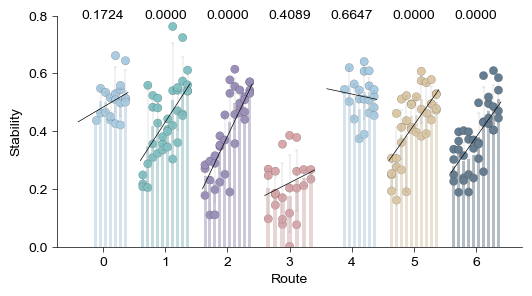

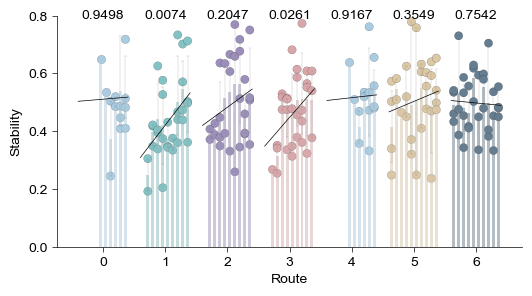

In [ ]:
if exists(join(figdata, f" {code_id} [Behav & Cross Day Stability].pkl")) == False:
    # code to generate and save the figure data
    BehavCrossStab = {
        "MiceID": [],
        "Session": [],
        "Behav Retriv": [],
        "Stability": [],
        "Route": []
    }
    
    for mouse in [10212, 10224, 10227, 10232]:
        behav_prop_r0 = hidden_state_proportion(mouse, 1, 0)
        mean_prop_r0 = np.nanmean(behav_prop_r0, axis=1)
        for s in range(6):
            for i, rt in enumerate([0,1,2,3,0,4,5]):
                
                behav_prop_rt = hidden_state_proportion(mouse, 1, rt)[CP_DSPs[1][rt]-1, s] / mean_prop_r0[CP_DSPs[1][rt]-1]
                with open(join(saved_dir, f"{mouse}_neural.pkl"), 'rb') as f:
                    neural_stability = pickle.load(f)[CP_DSPs[1][rt]-1, s, i, 0]
                    
                idx = np.where((np.isnan(neural_stability) == False)&(np.isnan(behav_prop_rt) == False))[0]
                behav_prop_rt = behav_prop_rt[idx]
                behav_prop_rt = (behav_prop_rt//0.1).astype(np.int64)
                behav_prop_rt = np.clip(behav_prop_rt, 0, 9)
                neural_stability = neural_stability[idx]
                
                for j in range(10):
                    idx = np.where(behav_prop_rt == j)[0]
                
                    BehavCrossStab['MiceID'].append(mouse)
                    BehavCrossStab['Session'].append(s)
                    BehavCrossStab['Behav Retriv'].append(np.mean(behav_prop_rt[idx]))
                    BehavCrossStab['Stability'].append(np.mean(neural_stability[idx]))
                    BehavCrossStab['Route'].append(i)
    
    for key in BehavCrossStab:
        BehavCrossStab[key] = np.asarray(BehavCrossStab[key])
        
    with open(join(figdata, f"{code_id} [Behav & Cross Day Stability].pkl"), "wb") as f:
        pickle.dump(BehavCrossStab, f)
        
    BehavCrossStabD = pd.DataFrame(BehavCrossStab)
    BehavCrossStabD.to_excel(join(figdata, f"{code_id} [Behav & Cross Day Stability].xlsx"), index=False)
    print(len(BehavCrossStabD))
else:
    with open(join(figdata, f"{code_id} [Behav & Cross Day Stability].pkl"), "rb") as f:
        BehavCrossStab = pickle.load(f)

for s in [0, 5]:
    subdata_s = SubDict(
        BehavCrossStab,
        BehavCrossStab.keys(),
        np.where(BehavCrossStab['Session'] == s)[0]
    )
    fig = plt.figure(figsize=(6,3))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    colors = DSPPalette[:4] + [DSPPalette[0]] + DSPPalette[4:6]
    for rt in range(7):
        subdata_rt = SubDict(
            subdata_s,
            subdata_s.keys(),
            np.where(subdata_s['Route'] == rt)[0]
        )
        for k in subdata_rt.keys():
            if k not in ['Stability', 'Behav Retriv']:
                subdata_rt[k] = np.concatenate([subdata_rt[k], [0, 0, 0, 0, 0]])
            else:
                if k == 'Stability':
                    subdata_rt[k] = np.concatenate([subdata_rt[k], [np.nan, np.nan, np.nan, np.nan, np.nan]])
                elif k == 'Behav Retriv':
                    subdata_rt[k] = np.concatenate([subdata_rt[k], [0,1,2,3,4]])

            
        sns.stripplot(
            x='Route',
            y='Stability',
            hue='Behav Retriv',
            data=pd.DataFrame(subdata_rt),
            palette=[colors[rt]] * 10,
            linewidth=0.1,
            dodge=True,
            jitter=0,
            size=6,
            edgecolor='black',
            legend=False,
            zorder = 1
        )
        sns.barplot(
            x='Route',
            y='Stability',
            hue='Behav Retriv',
            data=pd.DataFrame(subdata_rt),
            palette=[colors[rt]] * 10,
            capsize=0.4,
            err_kws={"linewidth":0.15, 'color':'gray'},
            legend=False,
            zorder = 2,
            gap=0.4,
            alpha=0.5
        )
        x = np.linspace(0, 5, 2)
        xx = np.linspace(-0.4, 0.4, 2)
        idx = np.where(np.isnan(subdata_rt['Stability']) == False)[0]

        r1 = linregress(subdata_rt['Behav Retriv'][idx], subdata_rt['Stability'][idx])
        y = r1.slope * x + r1.intercept
        ax.plot(xx+rt, y, color='k', linewidth=0.5, zorder=3)
        ax.text(rt, 0.8, f"{r1.pvalue:.4f}", ha='center', va='center')
        ax.set_ylim(-0,0.8)
        ax.set_yticks(np.linspace(0, 0.8, 5))
    plt.savefig(join(loc, f"Behav Retriv S{s}.png"), dpi=300)
    plt.savefig(join(loc, f"Behav Retriv S{s}.svg"), dpi=300)
    plt.show()
        
        

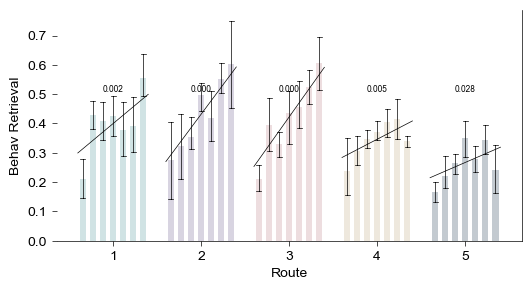

In [20]:
if exists(join(figdata, f"{code_id} [Behavioral Neural Retrieval Changes].pkl")) == False:
    RetrivDurChange = {
        "MiceID": [],
        "Route": [],
        "Session": [],
        "Behav Retrieval": [],
        "Neural Retrieval": []
    }
    
    for mouse in [10212, 10224, 10227, 10232]:
        with open(join(dir_name, f"{mouse}.pkl"), 'rb') as f:
            res = pickle.load(f)
        
        for s in range(7):
            for rt in range(1, 6):
                # Neural Retrieval
                pv = apvc(mouse, rt)[CP_DSPs[1][rt]-1, s, rt-1] if rt in [1,2,3] else apvc(mouse, rt)[CP_DSPs[1][rt]-1, s, rt]
                
                # Behavioral Retrieval
                behav_prop_rt = hidden_state_proportion(mouse, 1, rt)[CP_DSPs[1][rt]-1, s]
                
                RetrivDurChange["MiceID"].append(mouse)
                RetrivDurChange["Route"].append(rt)
                RetrivDurChange["Session"].append(s)
                RetrivDurChange["Behav Retrieval"].append(np.mean(behav_prop_rt[:10]))
                RetrivDurChange["Neural Retrieval"].append(np.mean(pv[:10]))
                
    
    for key in RetrivDurChange:
        RetrivDurChange[key] = np.array(RetrivDurChange[key])

    with open(join(figdata, f"{code_id} [Behavioral Neural Retrieval Changes].pkl"), 'wb') as f:
        pickle.dump(RetrivDurChange, f)
        
    RetrivDurChangeD = pd.DataFrame(RetrivDurChange)
    RetrivDurChangeD.to_excel(join(figdata, f"{code_id} [Behavioral Neural Retrieval Changes].xlsx"), index=False)
    print(len(RetrivDurChangeD))
else:
    with open(join(figdata, f"{code_id} [Behavioral Neural Retrieval Changes].pkl"), 'rb') as f:
        RetrivDurChange = pickle.load(f)

fig = plt.figure(figsize=(6, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'left'], ifxticks=True, ifyticks=True)
for rt in range(1, 6):
    subdata_rt = SubDict(
        RetrivDurChange,
        RetrivDurChange.keys(),
        np.where(RetrivDurChange["Route"] == rt)[0]
    )
    sns.barplot(
        x="Route",
        y="Behav Retrieval",
        data=subdata_rt,
        hue="Session",
        palette=[DSPPalette[rt]]*7,
        capsize=0.4, 
        err_kws={'linewidth': 0.5, 'color':'k'},
        legend=False,
        gap=0.4,
        width=0.8,
        zorder=2,
        alpha=0.4
    )
    idx = np.where(np.isnan(subdata_rt["Behav Retrieval"]) == False)[0]
    res = linregress(subdata_rt["Session"][idx], subdata_rt["Behav Retrieval"][idx])
    x = np.linspace(0, 6, 2)
    xx = np.linspace(-0.4, 0.4, 2)+rt-1
    y = res.intercept + res.slope*x
    ax.plot(xx, y, color='k', linewidth=0.5)
    ax.text(rt-1, 0.5, f"{res.pvalue:.3f}", ha='center', va='bottom', fontsize=6)

plt.show()

# Behavioral Retrieval Duration vs. Neural Retrieval Duration

140


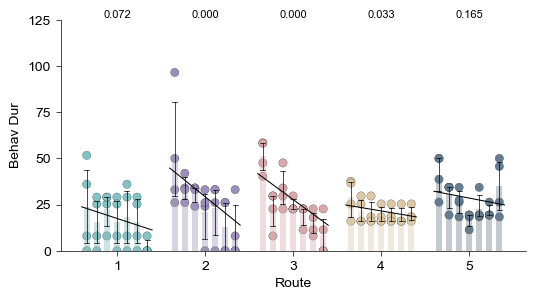

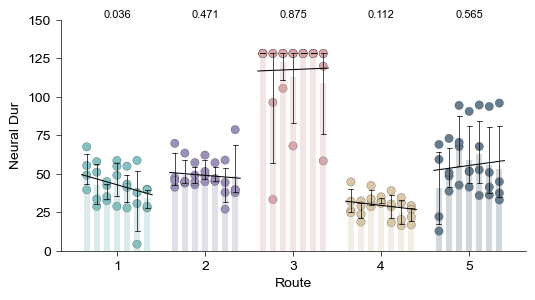

In [31]:
def compute_iqr(data, confidence=0.95):
    """data: 2d numpy array"""
    mean = np.mean(data, axis=1)
    q75, q25 = np.percentile(data, [75 ,25], axis=1)
    iqr = q75 - q25
    return mean - 1.5*iqr



if exists(join(figdata, f" {code_id} [Behavior vs Stability].pkl")) == False:
    BehavStab = {
        "MiceID": [],
        "Route": [],
        "Session": [],
        "Behav Dur": [],
        "Neural Dur": []
    }
    
    D = GetDMatrices(1, 48)
    D2 = GetDMatrices(1, 12)
    for mouse in [10212, 10224, 10227, 10232]:
        with open(join(dir_name, f"{mouse}.pkl"), 'rb') as f:
            res = pickle.load(f)
            
        loss_traj = res['raw_smoothed_loss_traj']
        route_traj = res['raw_route_traj']
        session_traj = res['raw_session_traj']
        lap_traj = res['raw_lap_traj']
        nodes_traj = res['raw_nodes_traj']
        retriev_state_traj = res['raw_retriv_state_traj']
        
        for s in range(7):
            behav_prop_0 = hidden_state_proportion(mouse, 1, 0)
            behav_thre = compute_iqr(behav_prop_0)

            
            for rt in range(1, 6):
                idx = np.where((session_traj == s) & (route_traj == rt))[0]
                dlap = np.where(np.diff(lap_traj[idx]) != 0)[0]
                beg = np.concatenate([[0], dlap + 1])
                end = np.concatenate([dlap+1, [idx.shape[0]]])
                
                sp = SP_DSPs[1][rt] # Starting point
                
                retriev_dist = np.zeros(beg.shape[0])
                for i in range(beg.shape[0]):
                    if route_traj[idx[beg[i]]] == 0:
                        continue
                    
                    
                    retriev_idx = np.where(retriev_state_traj[idx[beg[i]:end[i]]] == 1)[0]
                    if retriev_idx.shape[0] > 0:
                        retriev_pos = nodes_traj[idx[beg[i]:end[i]]][retriev_idx[0]]
                        retriev_dist[i] = D[retriev_pos-1, sp-1]
                    else:
                        # Whole range.
                        retriev_dist[i] = D[2303, sp-1]
                        
                    
                retriev_dist = np.median(retriev_dist)
                
                # Behavioral Retrieval
                behav_prop_rt = hidden_state_proportion(mouse, 1, rt)[:, s]
                behav_prop_rt_sorted = behav_prop_rt[CP_DSPs[1][rt]-1]
                behav_prop_0_sorted = behav_thre[CP_DSPs[1][rt]-1]
                
                if rt in [1, 2, 3]:
                    retriev_idx = np.where(behav_prop_rt_sorted - behav_prop_0_sorted*0.5 >= 0)[0]
                else: 
                    retriev_idx = np.where(behav_prop_rt_sorted[rt-2:] - behav_prop_0_sorted[rt-2:]*0.5 >= 0)[0]+rt-2

                if retriev_idx.shape[0] > 0:
                    retriev_pos = CP_DSPs[1][rt][retriev_idx[0]]
                    retriev_dist_behav = D2[S2F[sp-1]-1, retriev_pos-1]
                else:
                    retriev_dist_behav = D2[S2F[sp-1]-1, 143]
                    
                BehavStab['MiceID'].append(mouse)
                BehavStab['Route'].append(rt)
                BehavStab['Session'].append(s)
                BehavStab['Behav Dur'].append(retriev_dist_behav)
                BehavStab['Neural Dur'].append(retriev_dist)
        
    for k in BehavStab.keys():
        BehavStab[k] = np.array(BehavStab[k])
        
    with open(join(figdata, f"{code_id} [Behavior vs Stability].pkl"), 'wb') as f:
        pickle.dump(BehavStab, f)
        
    BehavStabD = pd.DataFrame(BehavStab)
    BehavStabD.to_excel(join(figdata, f"{code_id} [Behavior vs Stability].xlsx"), index=False)
    print(len(BehavStabD))
else:
    with open(join(figdata, f"{code_id} [Behavior vs Stability].pkl"), 'rb') as f:
        BehavStab = pickle.load(f)

fig = plt.figure(figsize=(6, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
for rt in range(1, 6):
    subdata_rt = SubDict(
        BehavStab, 
        BehavStab.keys(), 
        np.where(BehavStab['Route'] == rt)[0]
    )
    sns.stripplot(
        data=subdata_rt,
        x='Route',
        y='Behav Dur',
        hue='Session',
        palette=[DSPPalette[rt]]*7,
        ax=ax,
        size=6,
        dodge=True,
        jitter=0,
        edgecolor='k',
        linewidth=0.15,
        legend=False,
        zorder=1
    )
    sns.barplot(
        data=subdata_rt,
        x='Route',
        y='Behav Dur',
        hue='Session',
        palette=[DSPPalette[rt]]*7,
        ax=ax,
        capsize=0.4, 
        err_kws={'linewidth': 0.5, 'color':'k'},
        legend=False,
        gap=0.4,
        width=0.8,
        zorder=2,
        alpha=0.4
    )
    ax.set_ylim(0, 125)
    ax.set_yticks(np.linspace(0, 125, 6))
    idx = np.where(np.isnan(subdata_rt['Behav Dur']) == False)[0]
    res = linregress(subdata_rt['Session'][idx], subdata_rt['Behav Dur'][idx])
    x = np.linspace(0, 5, 2)
    xx = np.linspace(-0.4, 0.4, 2)+rt-1
    y = res.slope*x + res.intercept
    ax.plot(xx, y, color='k', linewidth=0.75)
    ax.text(rt-1, 125, f"{res.pvalue:.3f}", ha='center', va='bottom', fontsize=8)
plt.savefig(join(loc, f"Behavioral Retrieval Duration.png"), dpi=300, bbox_inches='tight')
plt.savefig(join(loc, f"Behavioral Retrieval Duration.svg"), dpi=300, bbox_inches='tight')
plt.show()

fig = plt.figure(figsize=(6, 3))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
for rt in range(1, 6):
    subdata_rt = SubDict(
        BehavStab, 
        BehavStab.keys(), 
        np.where(BehavStab['Route'] == rt)[0]
    )
    sns.stripplot(
        data=subdata_rt,
        x='Route',
        y='Neural Dur',
        hue='Session',
        palette=[DSPPalette[rt]]*7,
        ax=ax,
        size=6,
        dodge=True,
        jitter=0,
        edgecolor='k',
        linewidth=0.15,
        legend=False,
        zorder=1
    )
    sns.barplot(
        data=subdata_rt,
        x='Route',
        y='Neural Dur',
        hue='Session',
        palette=[DSPPalette[rt]]*7,
        ax=ax,
        alpha=0.3,
        edgecolor=None,
        err_kws={'linewidth':0.5, 'color': 'k'},
        capsize=0.4,
        legend=False,
        gap=0.4,
        zorder=2
    )
    ax.set_ylim(0, 150)
    ax.set_yticks(np.linspace(0, 150, 7))
    idx = np.where(np.isnan(subdata_rt['Neural Dur']) == False)[0]
    res = linregress(subdata_rt['Session'][idx], subdata_rt['Neural Dur'][idx])
    x = np.linspace(0, 5, 2)
    xx = np.linspace(-0.4, 0.4, 2)+rt-1
    y = res.slope*x + res.intercept
    ax.plot(xx, y, color='k', linewidth=0.75)
    ax.text(rt-1, 150, f"{res.pvalue:.3f}", ha='center', va='bottom', fontsize=8)
plt.savefig(join(loc, f"Neural Retrieval Duration.png"), dpi=300, bbox_inches='tight')
plt.savefig(join(loc, f"Neural Retrieval Duration.svg"), dpi=300, bbox_inches='tight')
plt.show()